<a href="https://colab.research.google.com/github/vtu27065/Deep-Learning/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu


100%|██████████| 170M/170M [30:58<00:00, 91.7kB/s]


Training images: 50000
Testing images: 10000


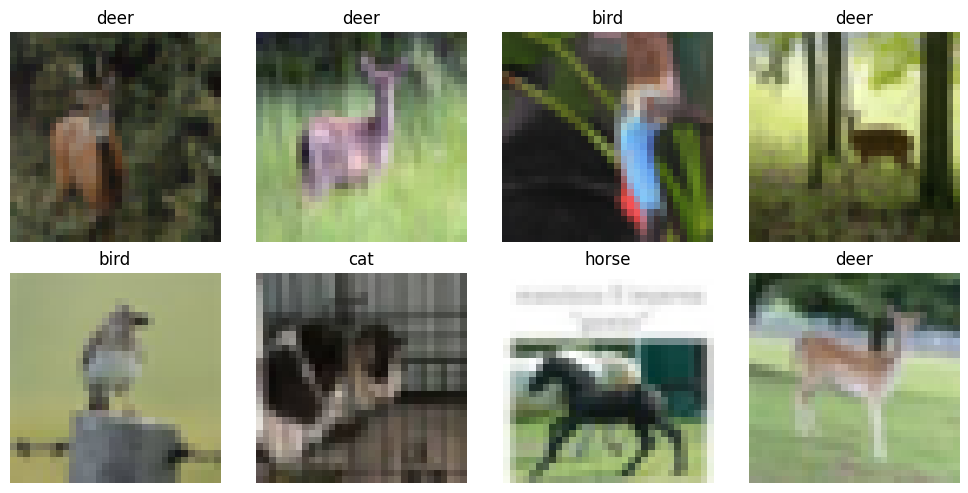

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)
Epoch [1/10] Loss: 1.3460 Accuracy: 51.63%
Epoch [2/10] Loss: 0.9650 Accuracy: 66.11%
Epoch [3/10] Loss: 0.8037 Accuracy: 72.01%
Epoch [4/10] Loss: 0.6841 Accuracy: 76.14%
Epoch [5/10] Loss: 0.5761 Accuracy: 79.96%
Epoch [6/10] Loss: 0.4795 Accuracy: 83.35%
Epoch [7/10] Loss: 0.3925 Accuracy: 86.30%
Epoch [8/10] Loss: 0.3101 Accuracy: 89.23%
Epoch [9/10] Loss: 0.2392 Accuracy: 91.76%
Epoch [10/10] Loss: 0.1817 Accuracy: 93.79%


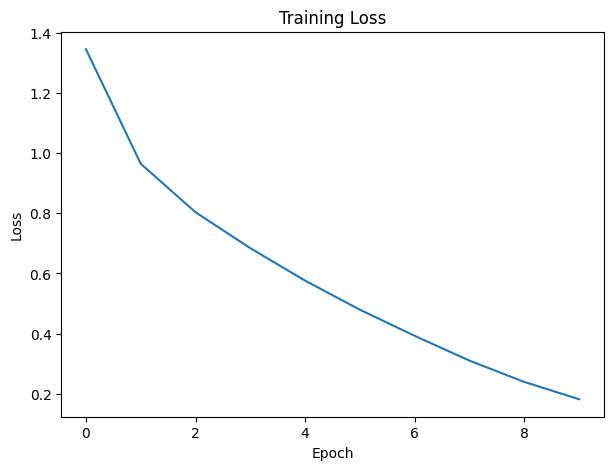

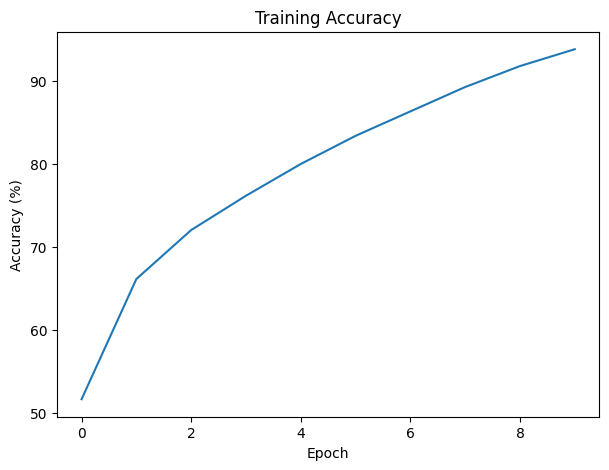

Test Accuracy: 70.88%

Class-wise Accuracy:
airplane    : 68.40%
automobile  : 80.80%
bird        : 62.00%
cat         : 59.50%
deer        : 61.50%
dog         : 67.00%
frog        : 75.70%
horse       : 75.50%
ship        : 81.60%
truck       : 76.80%


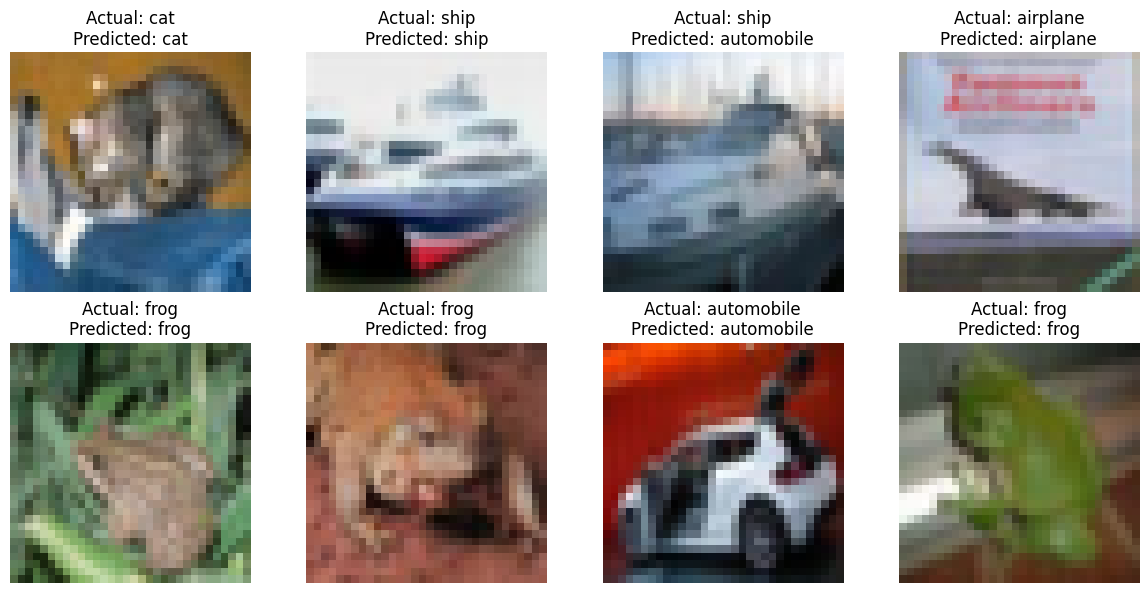

Model saved successfully as cnn_cifar10.pth


In [ ]:
# ============================================================
# TASK 2: CNN IMAGE CLASSIFICATION USING PYTORCH
# Dataset: CIFAR-10
# ============================================================

# Step 1: Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# Step 2: Define Image Transformations
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


# ============================================================
# Step 3: Load CIFAR-10 Dataset
# ============================================================

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# Step 4: Create Data Loaders
# ============================================================

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))


# ============================================================
# Step 5: Display Sample Images
# ============================================================

classes = (
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

images, labels = next(iter(train_loader))

# Display first 8 images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image = images[i] / 2 + 0.5
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# Step 6: Define CNN Model
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        # Convolution Layer 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Convolution Layer 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Pooling Layer
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        # ReLU activation
        self.relu = nn.ReLU()

    def forward(self, x):

        # Conv1 -> ReLU -> Pool
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Conv2 -> ReLU -> Pool
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected
        x = self.fc1(x)
        x = self.relu(x)

        # Output layer
        x = self.fc2(x)

        return x


# Create model
model = CNN().to(device)

print(model)


# ============================================================
# Step 7: Define Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# ============================================================
# Step 8: Train the CNN Model
# ============================================================

num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


# ============================================================
# Step 9: Plot Training Loss
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()


# ============================================================
# Step 10: Plot Training Accuracy
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.show()


# ============================================================
# Step 11: Evaluate Model on Test Dataset
# ============================================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


test_accuracy = 100 * correct / total

print("Test Accuracy: {:.2f}%".format(test_accuracy))


# ============================================================
# Step 12: Class-wise Accuracy
# ============================================================

class_correct = [0] * 10
class_total = [0] * 10

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            label = labels[i]

            class_total[label] += 1

            if predicted[i] == label:
                class_correct[label] += 1


print("\nClass-wise Accuracy:")

for i in range(10):

    accuracy = 100 * class_correct[i] / class_total[i]

    print(
        f"{classes[i]:12s}: {accuracy:.2f}%"
    )


# ============================================================
# Step 13: Test Prediction on Sample Images
# ============================================================

images, labels = next(iter(test_loader))

images_device = images.to(device)

model.eval()

with torch.no_grad():

    outputs = model(images_device)

    _, predictions = torch.max(outputs, 1)


# Display predictions
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i] / 2 + 0.5
    image = image.permute(1, 2, 0)

    ax.imshow(image)

    actual = classes[labels[i]]
    predicted = classes[predictions[i].cpu()]

    ax.set_title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    ax.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# Step 14: Save the Trained Model
# ============================================================

torch.save(
    model.state_dict(),
    "cnn_cifar10.pth"
)

print("Model saved successfully as cnn_cifar10.pth")